In [ ]:
import warnings, os
warnings.filterwarnings("ignore")  # keep the notebook readable

from methylbert.utils import set_seed
set_seed(42)

# ---- KNOBS (smoke run) ----------------------------------------------------
DATA_DIR   = os.path.expanduser("/tmp/bauerste/dmr100/")
TRAIN_CSV  = os.path.join(DATA_DIR, "train_seq.csv")
EVAL_CSV   = os.path.join(DATA_DIR, "test_seq.csv")

# Your pretrained checkpoint dir (config.json + weights). For a stability
# smoke run either the methylation-aware OR ablation checkpoint is fine -
# you are testing the optimizer, not comparing models. FILL THIS IN:
PRETRAINED = os.path.expanduser("/home/bauerste//methylbert_pretrain_with_methylation/pretrained_model_120k_512_w_methylation/step_120000")

OUTPUT     = "/home/bauerste/methylbert_finetune/finetune_out/"     # train.csv / eval.csv land here

SEQ_LEN    = 511              # -> 512 after SOS/EOS. MUST match pretraining.
N_MERS     = 3
BATCH      = 32               # OOM lever (see note above the train cell)
GRAD_ACCUM = 2
NUM_WORKERS= 8
DECREASE_STEPS = 0

LR         = 1e-4             # MethylBERT paper's fine-tune lr = value under test.
                             # Trip-wire: NaN/runaway -> halve (2e-4, 1e-4, ...).
                             # (Authors' shipped code defaults to a calmer 1e-4.)
WARMUP     = 20              # SMOKE value - tiny so lr reaches peak fast within a
                             # few hundred steps. Real runs use a proper warmup.
EVAL_FREQ  = 10              # log/eval every 10 steps
STEPS      = 300             # enough to see NaN/stability; full overfit turn
                             # may need the longer real run to appear
LOSS       = "bce"           # balanced 48/52 labels -> plain CE. focal is for imbalance.

In [2]:
from torch.utils.data import DataLoader
from methylbert.data.vocab import MethylVocab
from methylbert.data.dataset import MethylBertFinetuneDataset

tokenizer = MethylVocab(N_MERS)

train_dataset = MethylBertFinetuneDataset(TRAIN_CSV, tokenizer, seq_len=SEQ_LEN)
eval_dataset  = MethylBertFinetuneDataset(EVAL_CSV,  tokenizer, seq_len=SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH, num_workers=NUM_WORKERS,
                          pin_memory=True, shuffle=True)
eval_loader  = DataLoader(eval_dataset,  batch_size=BATCH, num_workers=NUM_WORKERS,
                          pin_memory=True,  shuffle=False)

Building Vocab
Total number of sequences :  33432


# of reads in each label:  [16252. 17180.]
Total number of sequences :  5796
# of reads in each label:  [2758. 3038.]


In [3]:
print("train rows:", len(train_dataset))
print("num_dmrs (DMR embedding size):", train_dataset.num_dmrs())   # EXPECT 100
print("ctype label counts:", train_dataset.ctype_label_count)

item = train_dataset[0]
d, m = item["dna_seq"], item["methyl_seq"]
print("dna len / methyl len:", d.shape[0], m.shape[0])              # EXPECT 512 / 512
print("first token (SOS=3):", int(d[0]))
nz = (d != tokenizer.pad_index).nonzero().flatten()
print("last non-pad token (EOS=2):", int(d[nz[-1]]))
print("methyl alphabet:", set(m.tolist()))                          # subset of {0,1,2,3}
print("ctype_label:", item["ctype_label"])                          # 0 or 1

assert d.shape[0] == 512 and m.shape[0] == 512, "length != 512"
assert train_dataset.num_dmrs() == 100, "num_dmrs != 100 - did dmr_id leak in?"
print("\ncontract OK")

train rows: 33432
num_dmrs (DMR embedding size): 100
ctype label counts: [16252. 17180.]
dna len / methyl len: 512 512
first token (SOS=3): 3
last non-pad token (EOS=2): 2
methyl alphabet: {0, 1, 2, 3}
ctype_label: 1

contract OK


In [4]:
from methylbert.trainer import MethylBertFinetuneTrainer

trainer = MethylBertFinetuneTrainer(
    len(tokenizer),
    save_path=OUTPUT,
    train_dataloader=train_loader,
    test_dataloader=eval_loader,      # <- eval/early-stop set. NOT run-2.
    lr=LR,
    with_cuda=True,
    log_freq=10,
    eval_freq=EVAL_FREQ,
    warmup_step=WARMUP,
    decrease_steps=DECREASE_STEPS,
    gradient_accumulation_steps=GRAD_ACCUM,
    loss=LOSS,
)

trainer.load(PRETRAINED)   # newly-initialized-weight warnings are expected

The model is loaded on GPU
Restore the pretrained model /home/bauerste//methylbert_pretrain_with_methylation/pretrained_model_120k_512_w_methylation/step_120000
Cross entropy loss assigned


Some weights of MethylBertEmbeddedDMR were not initialized from the model checkpoint at /home/bauerste//methylbert_pretrain_with_methylation/pretrained_model_120k_512_w_methylation/step_120000 and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'dmr_encoder.0.weight', 'read_classifier.0.bias', 'read_classifier.0.weight', 'read_classifier.3.bias', 'read_classifier.3.weight', 'read_classifier.4.bias', 'read_classifier.4.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total Parameters: 287738370


In [5]:
trainer.train(steps=STEPS)

False


Training...:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/1:   0%|          | 0/300 [00:00<?, ?it/s]

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.



Train Step 0 iter - loss : 0.384399 / lr : 0.000000
Running time for iter = 0.46825337409973145
Step 0 loss (0.753494) is lower than the current min loss (inf). Save the model at /home/bauerste/methylbert_finetune/finetune_out/
Step:0 Model Saved on: /home/bauerste/methylbert_finetune/finetune_out/
Step 39 loss (0.723681) is lower than the current min loss (0.753494). Save the model at /home/bauerste/methylbert_finetune/finetune_out/
Step:39 Model Saved on: /home/bauerste/methylbert_finetune/finetune_out/
Step 49 loss (0.689583) is lower than the current min loss (0.723681). Save the model at /home/bauerste/methylbert_finetune/finetune_out/
Step:49 Model Saved on: /home/bauerste/methylbert_finetune/finetune_out/
Step 59 loss (0.611837) is lower than the current min loss (0.689583). Save the model at /home/bauerste/methylbert_finetune/finetune_out/
Step:59 Model Saved on: /home/bauerste/methylbert_finetune/finetune_out/
Step 69 loss (0.576619) is lower than the current min loss (0.6118

In [6]:
import pandas as pd
df_train = pd.read_csv(os.path.join(OUTPUT, "train.csv"), sep="\t")
df_eval  = pd.read_csv(os.path.join(OUTPUT, "eval.csv"),  sep="\t")

print("any NaN in train loss?", df_train["loss"].isna().any())   # MUST be False
print("\ntrain tail:\n", df_train.tail())
print("\neval tail:\n", df_eval.tail())

any NaN in train loss? False

train tail:
     step      loss  ctype_acc        lr
26   259  0.208236   0.815625  0.000057
27   269  0.158879   0.775000  0.000055
28   279  0.292498   0.768750  0.000053
29   289  0.137761   0.759375  0.000052
30   299  0.291171   0.693750  0.000050

eval tail:
     step      loss  ctype_acc
26   259  0.478749   0.745514
27   269  0.442550   0.742063
28   279  0.457817   0.760697
29   289  0.442785   0.758454
30   299  0.457011   0.725155


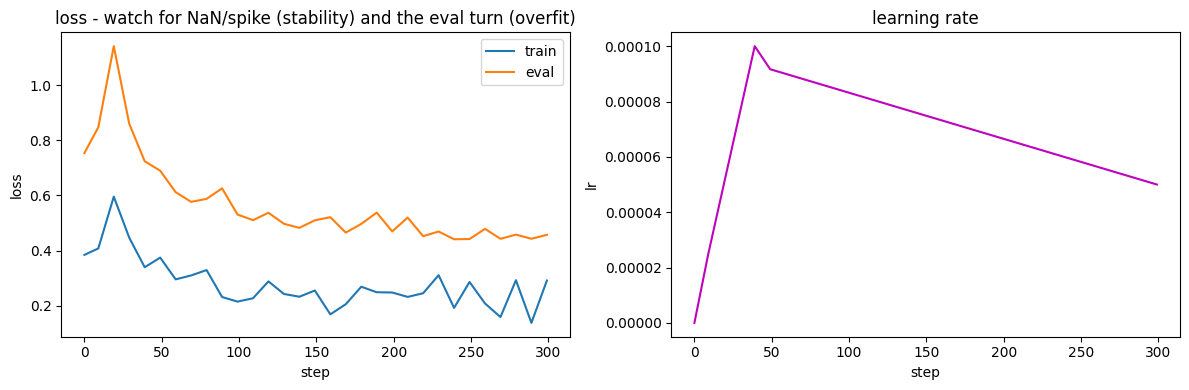

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=df_train, x="step", y="loss", label="train", ax=ax[0])
sns.lineplot(data=df_eval,  x="step", y="loss", label="eval",  ax=ax[0])
ax[0].set_title("loss - watch for NaN/spike (stability) and the eval turn (overfit)")
sns.lineplot(data=df_train, x="step", y="lr", color="m", ax=ax[1])
ax[1].set_title("learning rate")
plt.tight_layout(); plt.show()